# 08 — Multi-grating nitrogen abundances

Combine three gratings of the same source onto a common wavelength
grid (inverse-variance weighting), fit all lines simultaneously,
and compute N/O with the ICF scheme of your choice — all through
`compute_abundances`.

Source: Stark RXCJ2248-ID3 at z = 6.1052 (Berg+25).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jwspecfit
import jwspecmcmc
import jwspecabund
from jwspecfit.io import Spectrum
import numpyro
numpyro.set_host_device_count(6)

z = 6.1052
print(f'jwspecfit   v{jwspecfit.__version__}')
print(f'jwspecmcmc  v{jwspecmcmc.__version__}')
print(f'jwspecabund v{jwspecabund.__version__}')


jwspecfit   v1.0.1
jwspecmcmc  v1.0.1
jwspecabund v1.0.1


## 1. Load the three grating spectra


In [2]:
spec_g140m = jwspecfit.read_fits(
    '../../data/stark-rxcj2248-v4_g140m-f100lp_2478_3.spec.fits', z=z,
)
spec_g235m = jwspecfit.read_fits(
    '../../data/stark-rxcj2248-v4_g235m-f170lp_2478_3.spec.fits', z=z,
)
spec_g395m = jwspecfit.read_fits(
    '../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits', z=z,
)

for name, s in [('G140M', spec_g140m), ('G235M', spec_g235m), ('G395M', spec_g395m)]:
    v = s.mask_valid()
    print(f'{name}: {s.n_pix} px, {s.wave_um[v].min():.3f}-{s.wave_um[v].max():.3f} um')


G140M: 4667 px, 0.957-2.734 um
G235M: 3685 px, 1.605-4.574 um
G395M: 1661 px, 2.685-5.500 um


## 2. Inverse-variance combine onto a union grid

Build one `Spectrum` object covering the full wavelength range so
the fitter can tie line widths/centroids across the three gratings.


In [3]:
def combine_spectra_ivar(*spectra: Spectrum, z: float | None = None) -> Spectrum:
    """Inverse-variance combine spectra onto a union wavelength grid."""
    all_wave, all_flux, all_ivar = [], [], []
    for s in spectra:
        v = s.mask_valid()
        all_wave.append(s.wave_um[v])
        all_flux.append(s.flux_ujy[v])
        all_ivar.append(1.0 / s.err_ujy[v] ** 2)

    wave_union = np.sort(np.concatenate(all_wave))
    keep = np.ones(len(wave_union), dtype=bool)
    keep[1:] = np.diff(wave_union) > 1e-6
    wave_union = wave_union[keep]
    pixel_scale = float(np.median(np.diff(wave_union)))

    flux_out = np.zeros_like(wave_union)
    ivar_out = np.zeros_like(wave_union)
    for w, f, iv in zip(all_wave, all_flux, all_ivar):
        idx = np.clip(np.searchsorted(wave_union, w), 0, len(wave_union) - 1)
        good = np.abs(wave_union[idx] - w) < 0.5 * pixel_scale
        np.add.at(flux_out, idx[good], f[good] * iv[good])
        np.add.at(ivar_out, idx[good], iv[good])

    has = ivar_out > 0
    flux_out[has] /= ivar_out[has]
    err_out = np.full_like(wave_union, np.nan)
    err_out[has] = 1.0 / np.sqrt(ivar_out[has])
    flux_out[~has] = np.nan
    return Spectrum(
        wave_um=wave_union, flux_ujy=flux_out, err_ujy=err_out,
        grating=None, z=z,
    )

spec_combined = combine_spectra_ivar(spec_g140m, spec_g235m, spec_g395m, z=z)
v = spec_combined.mask_valid()
print(f'combined : {spec_combined.n_pix} px, '
      f'{spec_combined.wave_um[v].min():.3f}-{spec_combined.wave_um[v].max():.3f} um, '
      f'median SNR = {np.nanmedian(spec_combined.flux_ujy[v] / spec_combined.err_ujy[v]):.1f}')


combined : 7027 px, 0.957-5.500 um, median SNR = 1.0


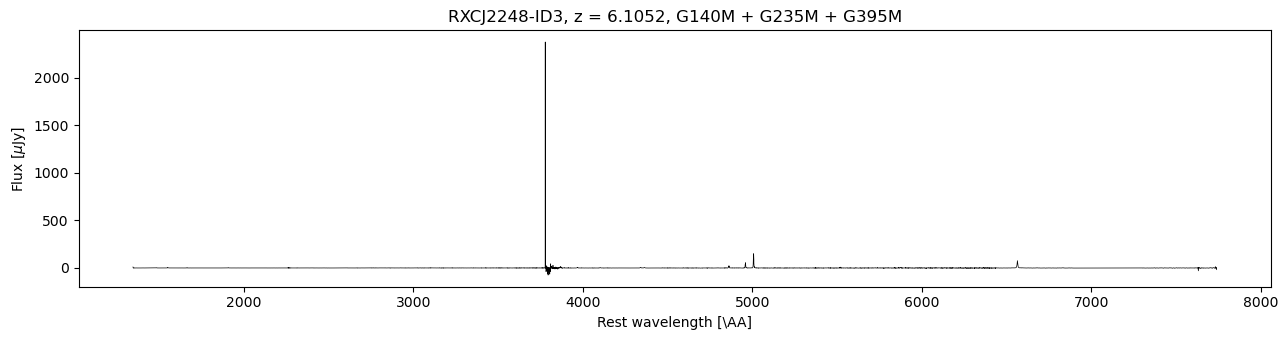

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.5))
rest_A = spec_combined.wave_um[v] / (1 + z) * 1e4
ax.plot(rest_A, spec_combined.flux_ujy[v], lw=0.5, color='k')
ax.set_xlabel(r'Rest wavelength [\AA]')
ax.set_ylabel(r'Flux [$\mu$Jy]')
ax.set_title(f'RXCJ2248-ID3, z = {z}, G140M + G235M + G395M')
fig.tight_layout()


## 3. Fit all lines simultaneously

Pick the lines you actually need for the abundance calculation —
the auroral line ([OIII] 4363) for T_e, density-sensitive doublets
for n_e, the Balmer series for A_V, and the nitrogen ions
(NIV/NIII] in UV, [NII] in optical) for N/O.


In [17]:
lines = [
    # Hydrogen Balmer series (dust + Te(low) recombination)
    'Ha', 'HBETA', 'HGAMMA', 'HDELTA', 'HEPSILON', 'H9', 'H10',
    # [OII] doublet (low-ionisation density + O+)
    'OII_doublet',
    # [OIII] (Te + O++)
    'OIII_4363', 'OIII_4959', 'OIII_5007',
    # [NII] doublet (N+; optical Te,low)
    'NII_6549', 'NII_6585',
    # [SII] doublet (low-ion density)
    'SII_6718', 'SII_6732',
    # [NeIII] (high-ion density + Ne/O)
    'NeIII_3869',
    # UV nitrogen ions (logU + N3+/N2+)
    'NIV_1483', 'NIV_1486', 'NIII_1749', 'NIII_1752',
    # UV carbon (C/O)
    'CIII]_1907', 'CIII]', 'CIV_1', 'CIV_2',
]

mcmc_result = jwspecmcmc.fit_lines(
    spec_combined, z=z,
    lines=lines,R=2700,
    sampler='nuts',
    n_warmup=500, n_samples_nuts=2000, n_chains=6, mode='off',
    tie_uv_centroids=True, tie_uv_widths=False, tie_uv_doublets=True,
)
result = mcmc_result.to_fit_result()

print(f'chi2/dof      : {result.chi2:.2f}')
print(f'R-hat max     : {mcmc_result.convergence["r_hat_max"]:.3f}')


Resolving power: R = 2700
Resolving power: R = 2700


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

18 divergent transitions detected (0.1%). Consider increasing target_accept_prob or max_tree_depth.


chi2/dof      : 1.35
R-hat max     : 1.084


In [18]:
fig = jwspecfit.plot_fit_interactive(result, rest_frame=True, flux_unit='fnu')
fig

## 4. Compute abundances (auto)


In [21]:
import logging
logging.getLogger("jwspecabund").setLevel(logging.ERROR)

abund = jwspecabund.compute_abundances(
    mcmc_result, z=z,
    method='auto',
    balmer_anchor='HBETA',
    dust_law='cardelli',
    n_posterior=500,
)
print(abund.summary())



N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: 1.2702e-06
  N++/H+: 3.3958e-06
  N+++/H+: 4.2611e-06
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: 2.3415e-07
  O++/H+: 2.1148e-05

--- Available diagnostics ---
  logU:   -2.481811515134
  Z/Zsun: 0.04365620560341724

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: ELIGIBLE (logU and Z/Zsun available)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): ELIGIBLE
  direct_sum (Tier 2/3 — UV N/O++): ELIGIBLE
  izotov06 (Tier 4 — N+/O+ fallback): ELIGIBLE

--- Final selection ---
  Chosen method:  martinez25
  ICF name:       NppNppp_Opp
  N/O value:      3.5094e-01



Strong-line (posterior): 100%|██████████| 500/500 [00:00<00:00, 11848.92it/s]

AbundanceResult (method=direct)
  12+log(O/H) = 7.330 +/- (0.0736282818786611, 0.07053009120831)
  log(N/O)    = -0.448 +/- (0.09330436717536794, 0.08097746035002557)
  log(C/O)    = -0.892 +/- (0.08602581271202514, 0.08194007468957443)
  log(S/O)    = FAILED — no S+ or S++ ions detected ([SII]/[SIII] missing)
  log(Ne/O)   = -1.082 +/- (0.031073195190211678, 0.035285595243559564)
  log(Ar/O)   = FAILED — no Ar++ ion detected ([ArIII] 7136 missing)
  T_e(high)   = 25717 +/- (2157.294900329991, 2787.480704785052) K
  T_e(low)    = 19935 +/- (1397.9270954138337, 1806.2874967007156) K
  n_e         = 300 cm^-3
  n_e(low)    = 300 cm^-3
  n_e(mid)    = 67412 cm^-3
  n_e(high)   = 155316 cm^-3
  log(U)      = -2.48 +/- (0.10495109676008418, 0.12934314652855816)
  A_V         = 0.044 +/- 0.091
  ICF method  = martinez25
  N/O ICF     = NppNppp_Opp

Ionisation correction factors:
  N/O: ICF = 0.9693 (Martinez+25 (NppNppp_Opp))  raw = -0.441  →  corrected = -0.455  (Δ = -0.014 dex)
  Ne/O: ICF

## 5. Compare ICF schemes for N/O

The recovered log(N/O) depends on which ICF you trust.
`compute_abundances` exposes four options:

| `icf_method` | What it does |
|---|---|
| `'auto'`        | Martinez+25 if log(U) is constrained, else Izotov+06 |
| `'martinez25'`  | Force Martinez+25 (logU-dependent) |
| `'izotov06'`    | Classical Izotov+06 (no logU) |
| `'direct_sum'`  | Sum N+ + N²⁺ + N³⁺ ions directly (no ICF) |


In [24]:
icf_methods = ['auto', 'martinez25', 'izotov06', 'direct_sum']
rows = []
for m in icf_methods:
    a = jwspecabund.compute_abundances(
        mcmc_result, z=z, method='direct',
        icf_method=m, n_posterior=500, progress=True,
    )
    rows.append((m, a))

print(f'{"icf":<14s} {"log(N/O)":>14s} {"log(U)":>10s} {"icf_name":>20s}')
print('-' * 62)
for m, a in rows:
    no_str = f'{a.NO:+.3f}' if a.NO is not None else '   FAILED'
    no_err = f'+/- {a.NO_err}' if a.NO_err is not None else ''
    logU_str = f'{a.logU:+.2f}' if a.logU is not None else '    -'
    icf_name = a.NO_icf_name or '-'
    print(f'{m:<14s} {no_str:>14s} {logU_str:>10s} {icf_name:>20s}  {no_err}')



N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: 1.2707e-06
  N++/H+: 3.4865e-06
  N+++/H+: 4.4014e-06
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: 2.3431e-07
  O++/H+: 2.1152e-05

--- Available diagnostics ---
  logU:   -2.481901034540541
  Z/Zsun: 0.043665682811738264

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: ELIGIBLE (logU and Z/Zsun available)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): ELIGIBLE
  direct_sum (Tier 2/3 — UV N/O++): ELIGIBLE
  izotov06 (Tier 4 — N+/O+ fallback): ELIGIBLE

--- Final selection ---
  Chosen method:  martinez25
  ICF name:       NppNppp_Opp
  N/O value:      3.6145e-01



Direct Te (posterior): 100%|██████████| 500/500 [02:02<00:00,  4.09it/s]

icf                  log(N/O)     log(U)             icf_name
--------------------------------------------------------------
auto                   -0.435      -2.48          NppNppp_Opp  +/- (0.09249890003789263, 0.08139301536846733)
martinez25             -0.435      -2.48          NppNppp_Opp  +/- (0.09249890003789263, 0.08139301536846733)
izotov06               +0.736      -2.48                    -  +/- (0.16933551438233774, 0.15224134166872005)
direct_sum             -0.364      -2.48          Np_Npp_Nppp  +/- (0.07890725095663992, 0.06935363804557992)


## 6. Posterior overlay


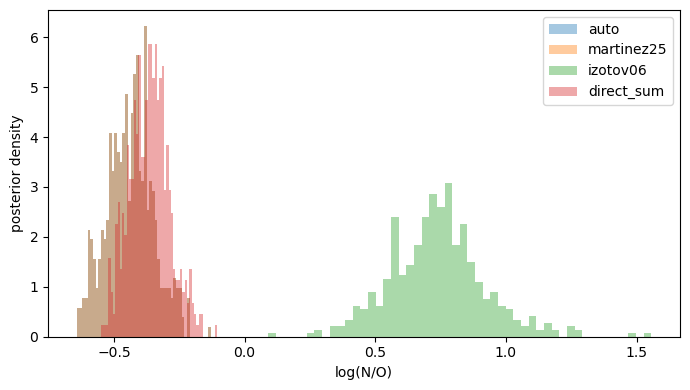

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
for m, a in rows:
    if a.NO_posterior is None:
        continue
    ax.hist(a.NO_posterior, bins=50, density=True, alpha=0.4, label=m)
ax.set_xlabel('log(N/O)')
ax.set_ylabel('posterior density')
ax.legend()
fig.tight_layout()
